# Introduction to Data Science - Week 6 
This week through my studies I have used code to show how to classify a breast cancer dataset using KNN and Decision Tree, and have visualised, analysed and observed the impact of different parameters and features on the performance of the model.

In [17]:
#Data and plotting imports
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

#Machine learning imports
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree

Here I have converted the data to a Pandas DataFrame for easy subsequent processing.

In [18]:
#Loading the breast cancer dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [19]:
# A Function to plot decision boundarys
def plot_decision(X,y,model,n_classes=2):
    min1, max1 = X[:, 0].min()-1, X[:, 0].max()+1
    min2, max2 = X[:, 1].min()-1, X[:, 1].max()+1
    x1grid = np.arange(min1, max1, 0.1)
    x2grid = np.arange(min2, max2, 0.1)
    xx, yy = np.meshgrid(x1grid, x2grid)
    grid = np.c_[xx.ravel(), yy.ravel()]
    model.fit(X, y)
    yhat = model.predict(grid)
    zz = yhat.reshape(xx.shape)
    plt.contourf(xx, yy, zz, cmap='coolwarm', alpha=0.8)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k')

### KNN

Here I have analysed the effect of different k values on the decision boundary. I used loops to plot decision boundaries for each of the three different k-values, using subplots on the same canvas to visualise the effect of k-value changes on the decision boundaries in a more intuitive way. In addition, I have selected two features for visualisation on the x-axis and y-axis and added captions to the data to make the comparison clearer.

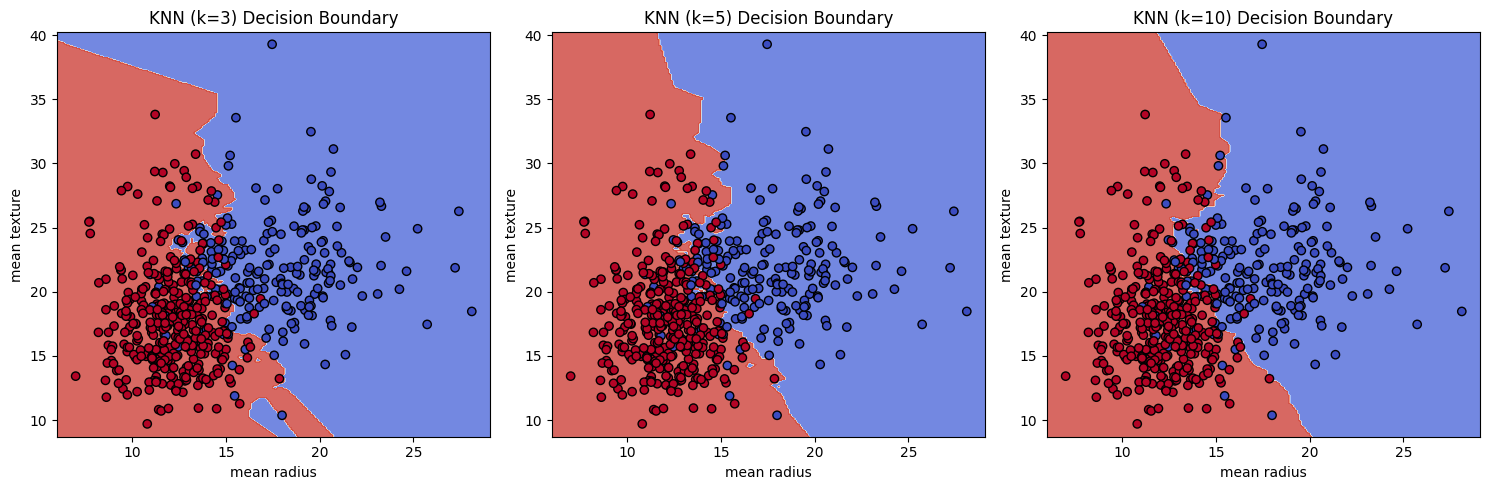

In [ ]:
#Pick two features
feature1 = 'mean radius'
feature2 = 'mean texture'
X = df[[feature1, feature2]].values
y = df['target'].values

#Comparison of different k values(3/5/10)
plt.figure(figsize=(15,5))
for i, k in enumerate([3, 5, 10]):
    plt.subplot(1, 3, i+1)
    model = KNeighborsClassifier(n_neighbors=k)
    plot_decision(X, y, model)
    plt.title(f'KNN (k={k}) Decision Boundary')
    plt.xlabel(feature1)
    plt.ylabel(feature2)
plt.tight_layout()
plt.show()

The final result obtained is that the boundary is more complex for k=3 and smoother for k=10, and the larger the value of k the smoother the boundary.

### Decision Trees

Here I have analysed the effect of max_depth of the decision tree on the decision boundary. I still used a loop to draw decision boundaries for each of the three different max_depth values.

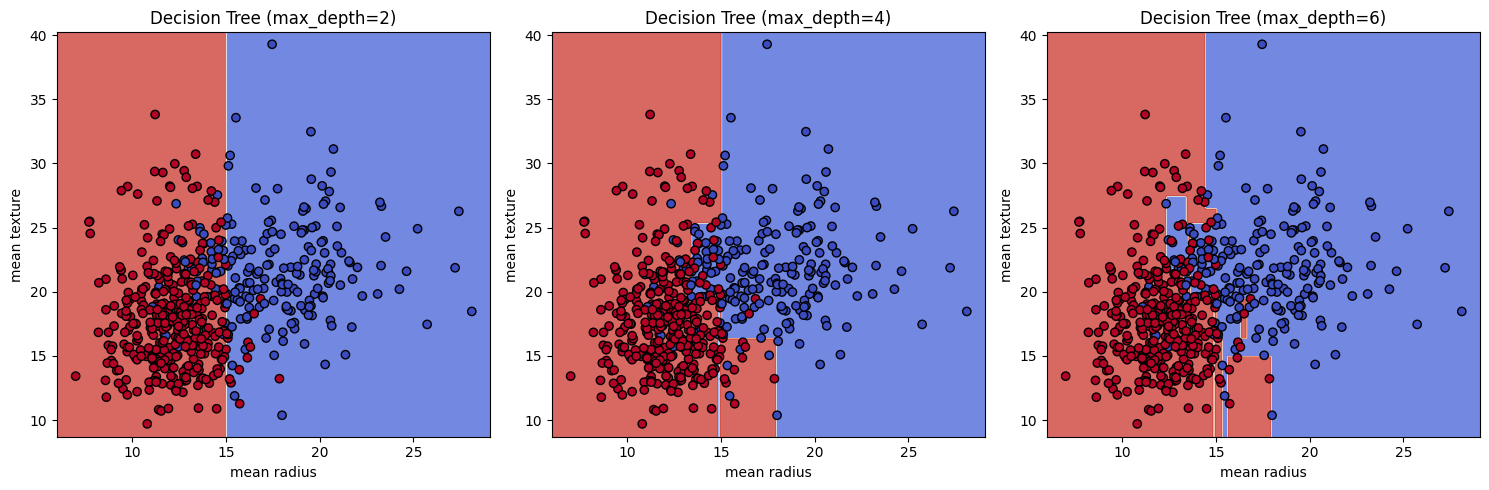

In [21]:
#Comparison of different depth values(2/4/6)
plt.figure(figsize=(15,5))
for i, depth in enumerate([2, 4, 6]):
    plt.subplot(1, 3, i+1)
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    plot_decision(X, y, model)
    plt.title(f'Decision Tree (max_depth={depth})')
    plt.xlabel(feature1)
    plt.ylabel(feature2)
plt.tight_layout()
plt.show()

I found that when max_depth=2 the boundaries are simple; when max_depth=6 the boundaries are complex. So I conclude that the greater the depth the more complex the boundary is.

### Feature Combination Experiment

Here I compare the effect of different combinations on the performance of decision trees by combining features.

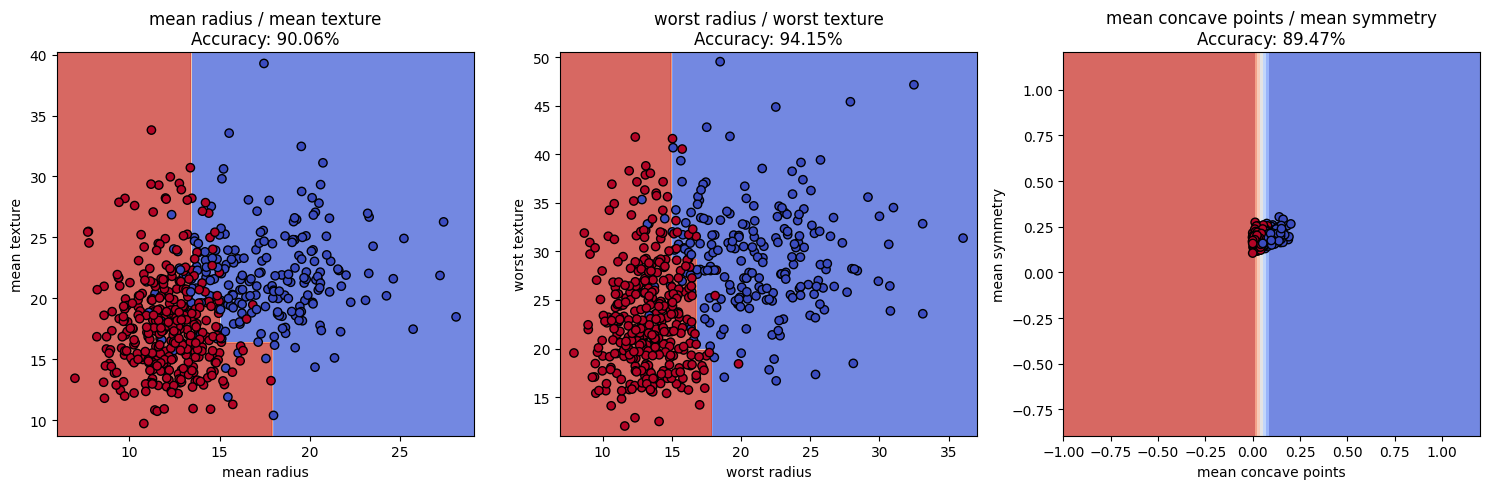

In [27]:
feature_pairs = [
    ('mean radius', 'mean texture'),
    ('worst radius', 'worst texture'),
    ('mean concave points', 'mean symmetry')
]

plt.figure(figsize=(15,5))
for i, (p1, p2) in enumerate(feature_pairs):
    X = df[[p1, p2]].values
    model = DecisionTreeClassifier(max_depth=3)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    
    plt.subplot(1, 3, i+1)
    plot_decision(X, y, model)
    plt.title(f'{p1} / {p2}\nAccuracy: {acc:.2%}')
    plt.xlabel(p1)
    plt.ylabel(p2)
plt.tight_layout()
plt.show()

Here I found that the accuracy of different combinations of feature test sets are different, and after adding Accuracy you can see more intuitively that the combination of ‘worst radius/worst texture’ is more effective and accurate.

### Using the Whole Feature Set

I used all 30 features to train the decision tree to help me evaluate performance and visualise the tree structure.


Accuracy: 0.9649122807017544


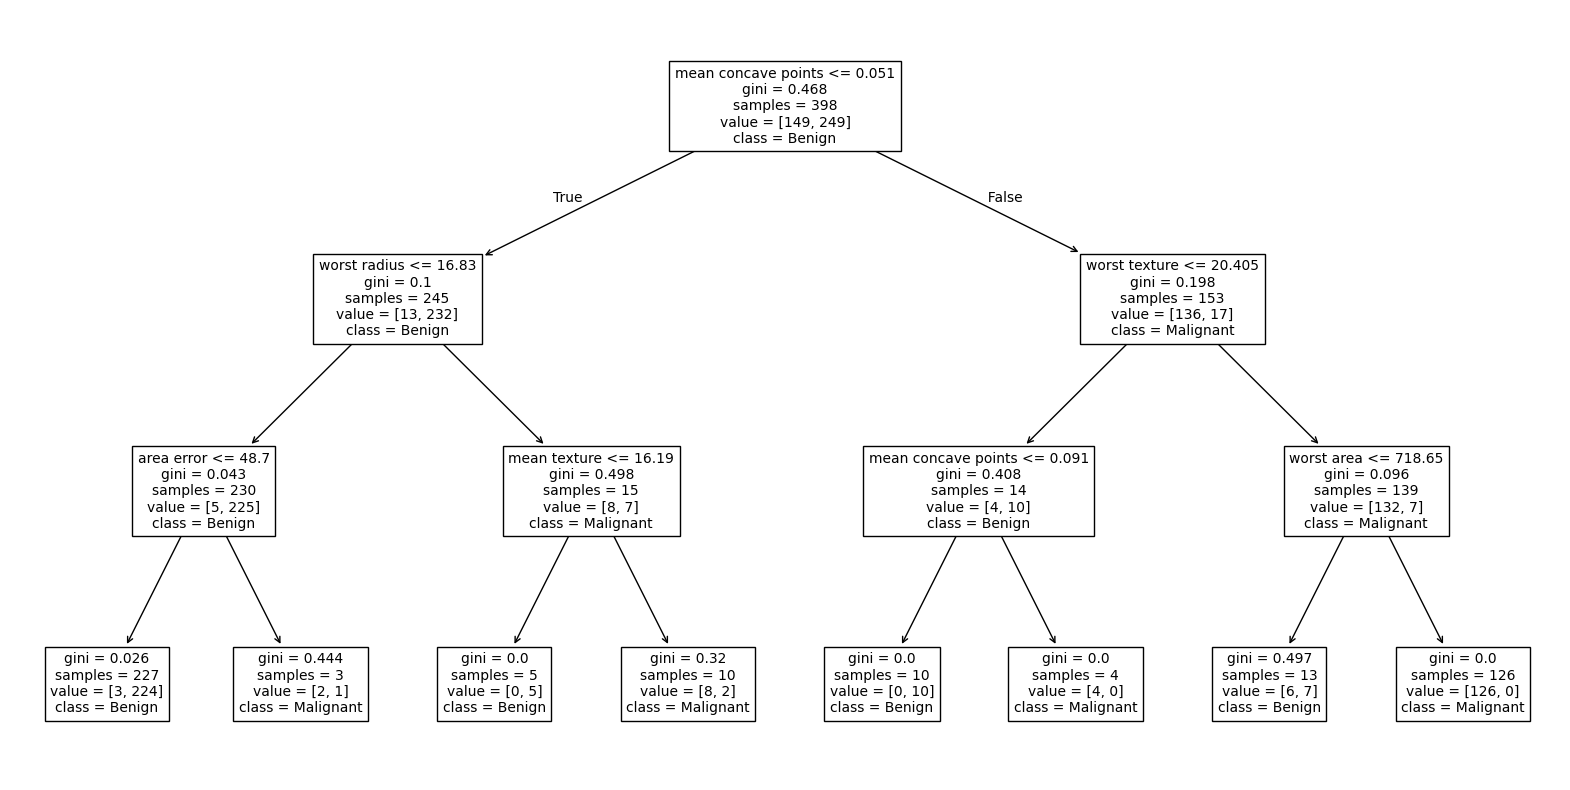

In [42]:
#Use all features
X = df.drop('target', axis=1).values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Fit model
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
print("\nAccuracy:", model.score(X_test, y_test))

plt.figure(figsize=(20,10))
my_plot = plot_tree(model, feature_names=data.feature_names,fontsize=10,class_names = ["Malignant","Benign"]) 

plt.show()

### Reflection

The interpretability and visualisation capabilities of KNNs and decision trees have been found to be excellent through learning. kNNs can intuitively show how the complexity of the model affects the boundaries by adjusting the value of k, and the splitting process of a decision tree allows for a clear visualisation of the data. For example, the data I quoted on breast cancer made me think that the interpretability of decision trees might help doctors with medical diagnosis?